# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

from environment.environment import Environment
from experiment import Experiment
from campaigns.uniform_bids_stochastic_campaign import UniformBidsStochasticCampaign
from bidders.UCB_based.ucb_like_bidder import UCBLikeBidder

import plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 1: Single campaign and stochastic environment

### Environment

Build a stochastic environment:
- A distribution over the highest competing bid

In [13]:
N_TRIALS = 10  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=1, campaign_type=UniformBidsStochasticCampaign, min_competitors=1, max_competitors=3, conflicts_percentage=0.0, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 100000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.075  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 1
Campaigns:
    -- CAMPAIGN: --
    Type: Uniform Bids
    Description: Competing bids sampled from a stochastic uniform distribution, maximum bid follows a Beta distribution.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
Conflicts graph matrix (1 = conflicting):
[[0]]


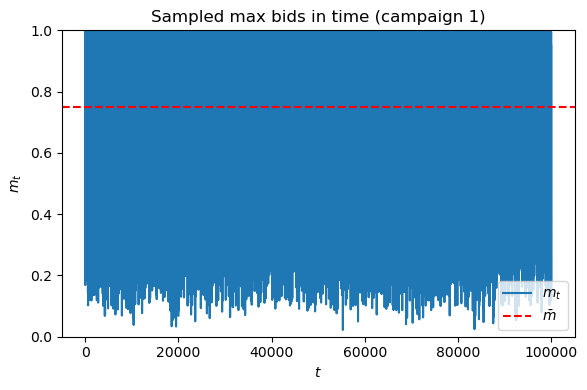

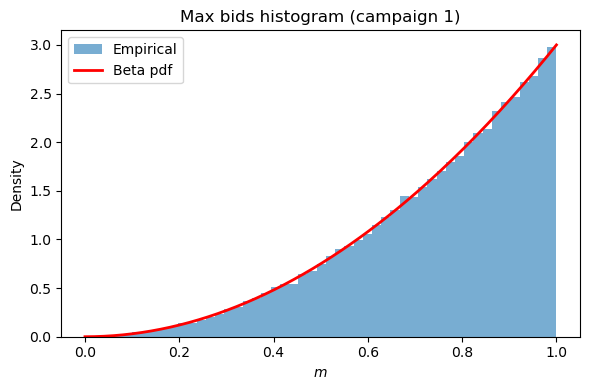

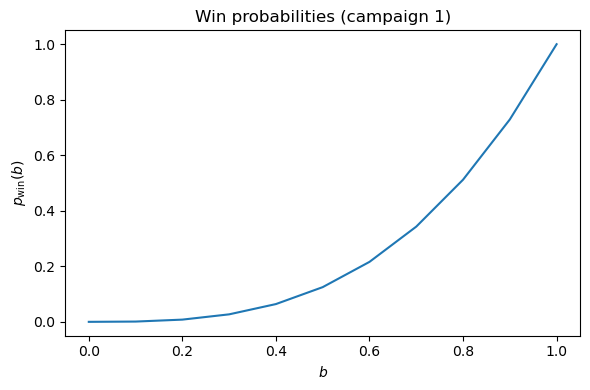

In [14]:
for campaign in environment.campaigns:
    campaign.generate_random_competing_bids(n_users=N_USERS, seed=47)  # generate random competing bids for each advertiser in the campaign

plots.plot_req1_sampled_max_bids_in_time(environment)
plots.plot_req1_max_bids_histogram(environment)
plots.plot_win_probabilities(environment, BIDS_SPACE, 'req1_win_probabilities.png')

### Design algorithms for a single campaign and stochastic environment
- Build a bidding strategy using UCB1 ignoring the budget constraint.
- Build a bidding strategy extending UCB1 to handle the budget constraint

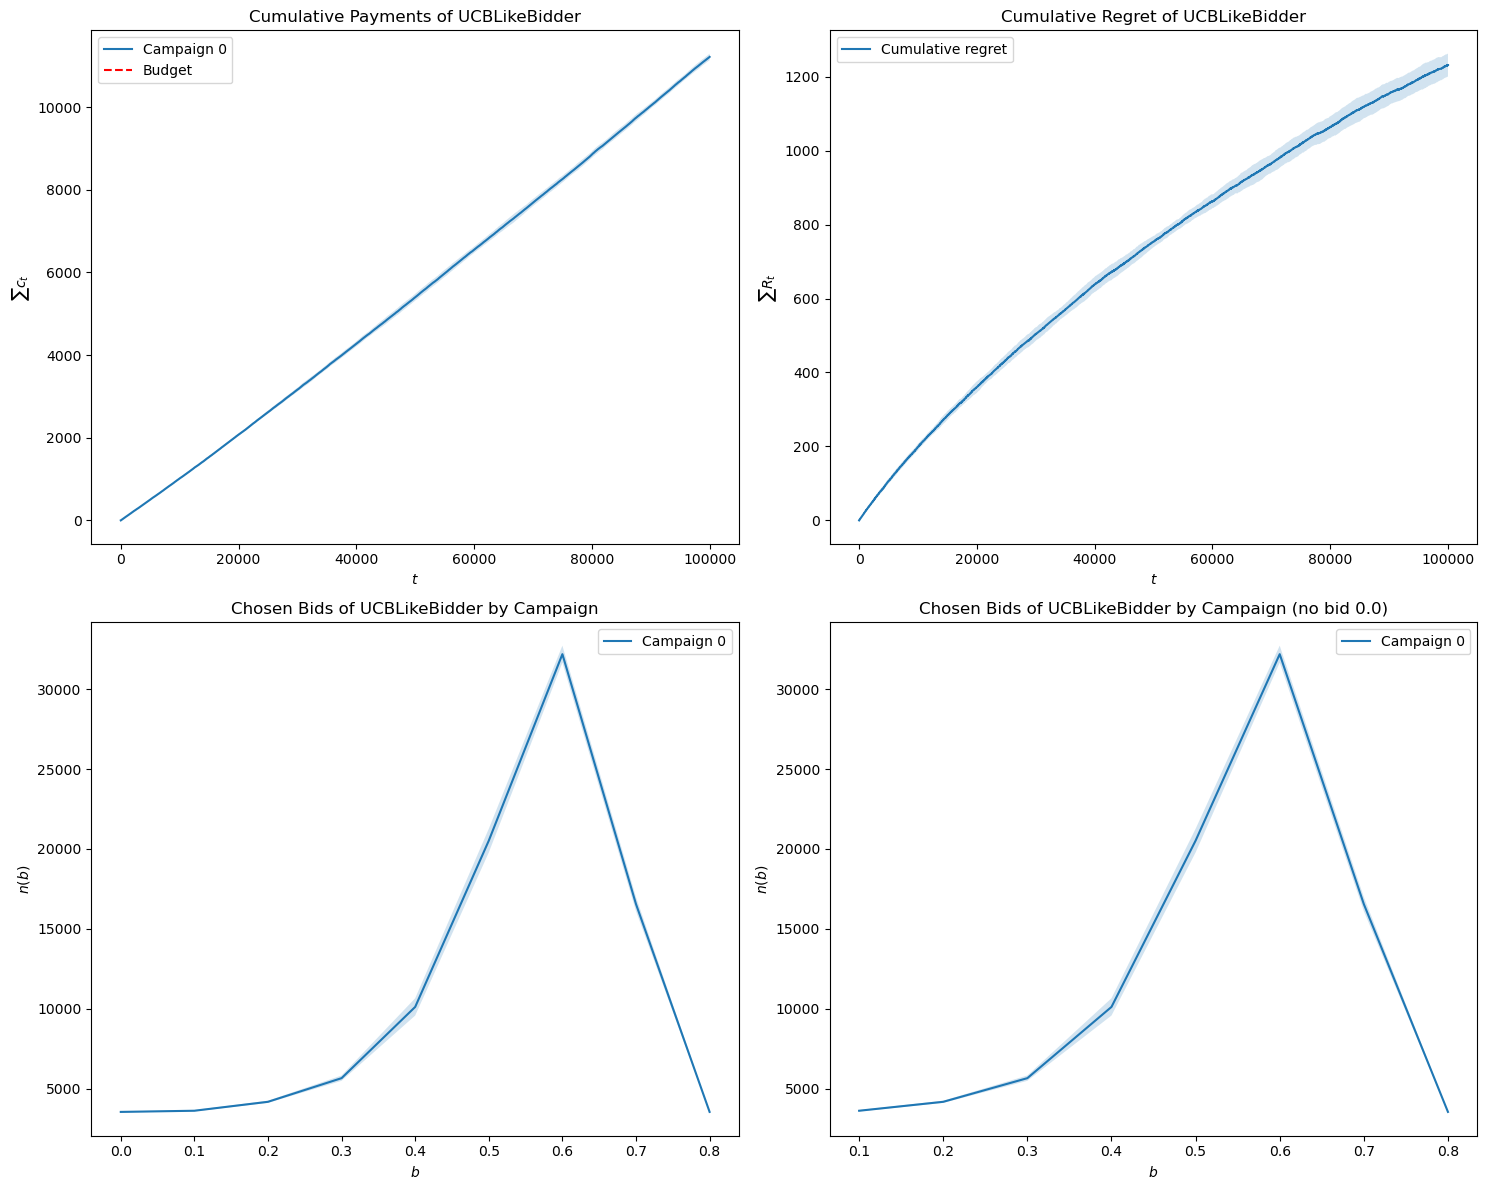

In [15]:
STARTING_BUDGET = np.inf          # RHO * N_USERS for budget or np.inf for no budget

no_budget_single_campaign_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=UCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment
                                                            })

no_budget_single_campaign_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simplified', seed=10)

plots.plot_experiment_result(no_budget_single_campaign_UCB_like_experiment, "req1_no_budget_experiment_results.png")

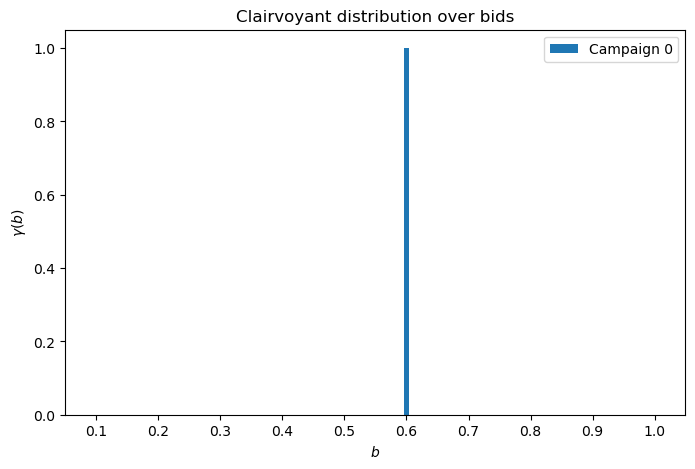

In [16]:
plots.plot_req1_clairvoyant_distribution_over_bids(no_budget_single_campaign_UCB_like_experiment, "req1_clairvoyant_gamma_no_budget.png")

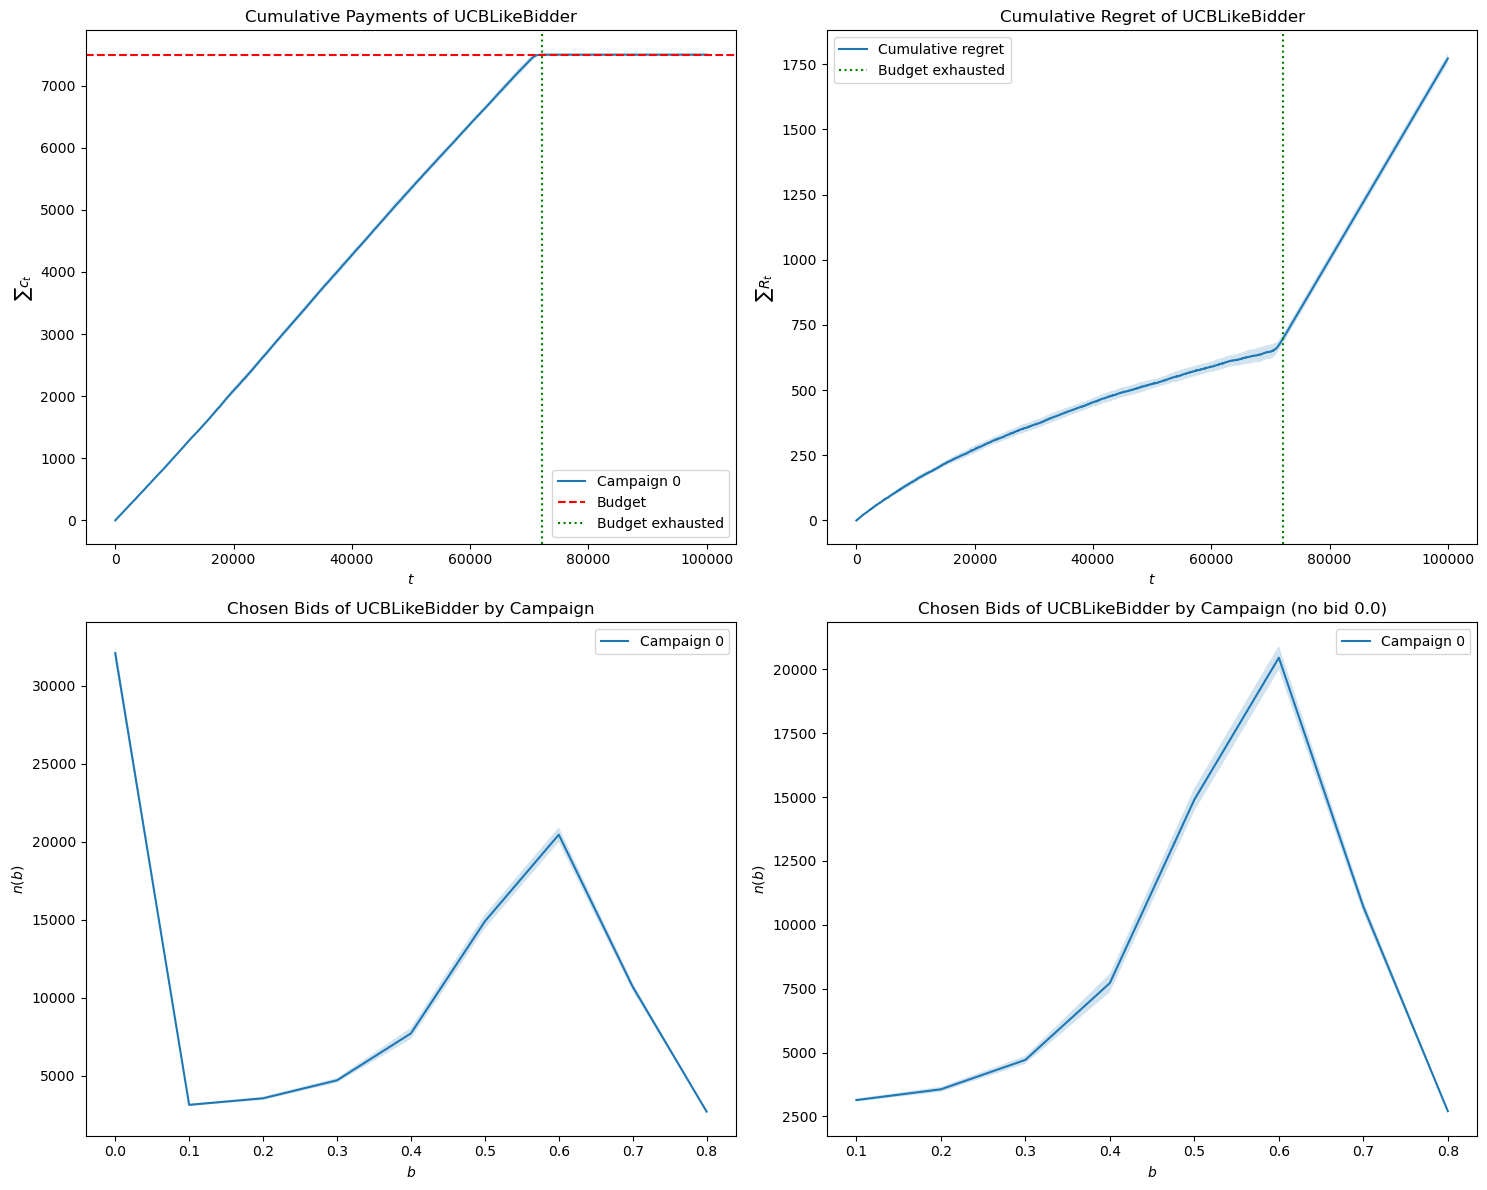

In [17]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

budget_constrained_single_campaign_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=UCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': [MY_VALUATION for _ in range(environment.N_CAMPAIGNS)], 
                                                              'environment': environment
                                                            })

budget_constrained_single_campaign_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='simplified', seed=10)

plots.plot_experiment_result(budget_constrained_single_campaign_UCB_like_experiment, "req1_budget_constrained_experiment_results.png")

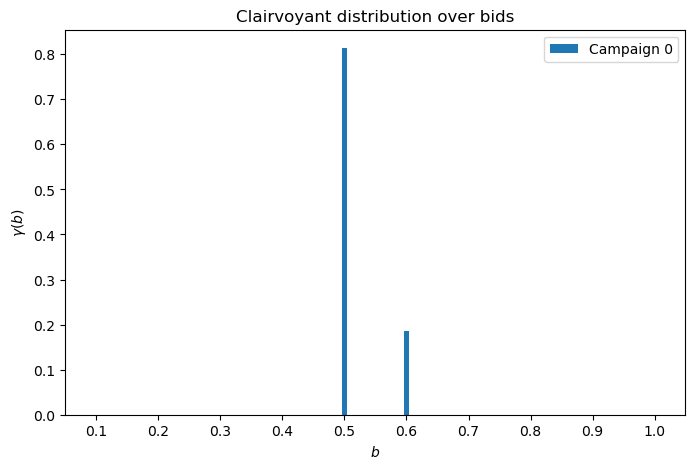

In [18]:
plots.plot_req1_clairvoyant_distribution_over_bids(budget_constrained_single_campaign_UCB_like_experiment, 'req1_clairvoyant_gamma_budget.png')

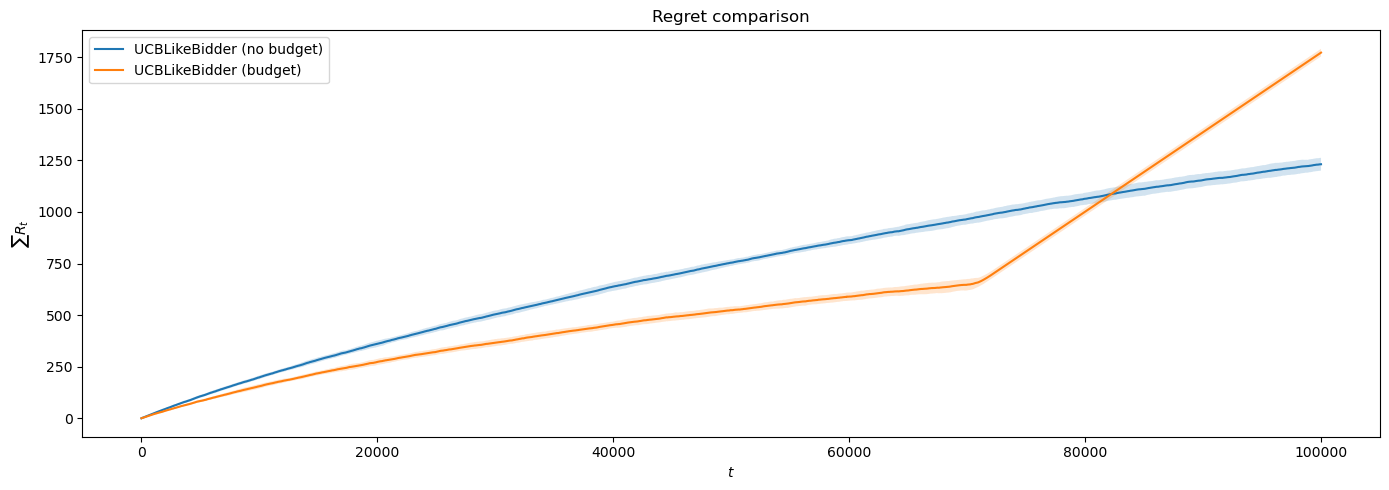

In [19]:
plots.plot_req1_nobudget_vs_budget_regrets_comparison(no_budget_single_campaign_UCB_like_experiment, budget_constrained_single_campaign_UCB_like_experiment)

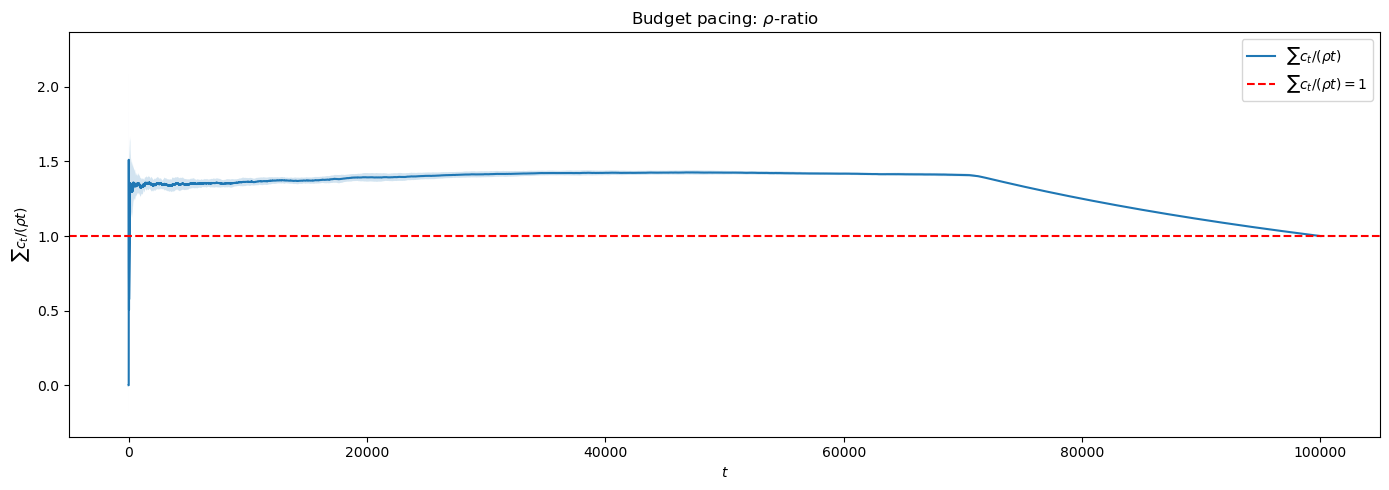

In [20]:
plots.plot_req1_budget_rho_ratio(budget_constrained_single_campaign_UCB_like_experiment)

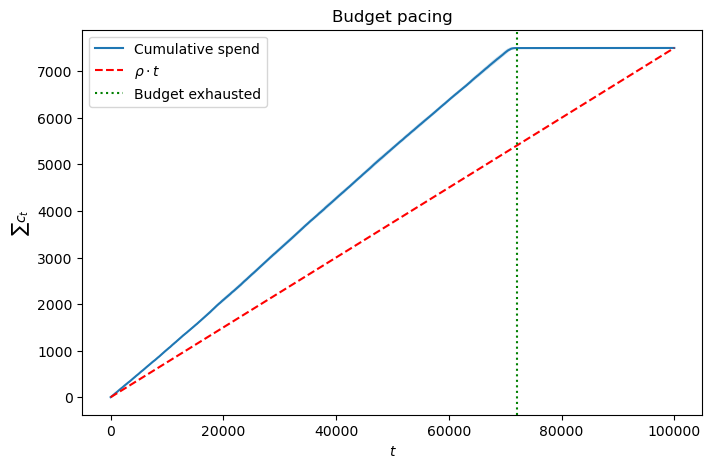

In [21]:
plots.plot_req1_budget_pacing(budget_constrained_single_campaign_UCB_like_experiment)

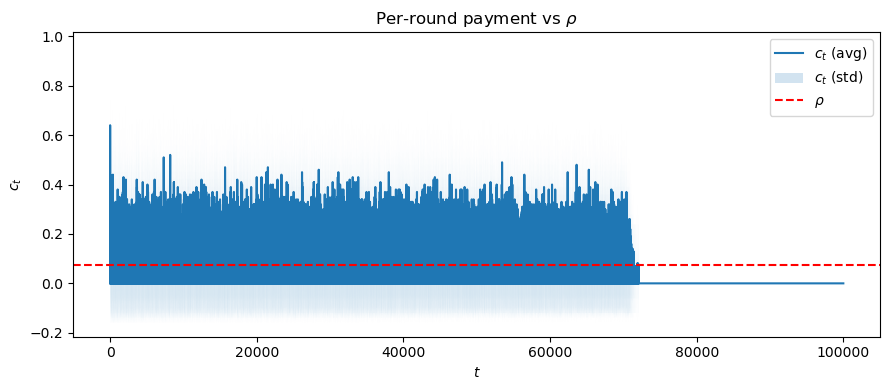

In [22]:
plots.plot_req1_per_round_payment_vs_rho(budget_constrained_single_campaign_UCB_like_experiment)